In [64]:
from sklearn.datasets import fetch_openml

In [65]:
mnist = fetch_openml('mnist_784', version= 1, as_frame= False)
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [66]:
x,y = mnist['data'],mnist['target']

In [67]:
x.shape

(70000, 784)

In [68]:
y.shape

(70000,)

In [69]:
%matplotlib inline

In [70]:
import matplotlib
import matplotlib.pyplot as plt

In [71]:
some_digit = x[3601]
some_digit_image = some_digit.reshape(28,28)

(-0.5, 27.5, 27.5, -0.5)

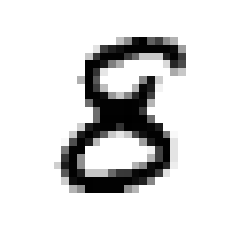

In [72]:
plt.imshow(some_digit_image,cmap=matplotlib.cm.binary , interpolation="nearest")
plt.axis("off")

In [74]:
y[3601]

'8'

In [75]:
x_train , x_test = x[0:6000],x[6000:7000]
y_train , y_test = y[0:6000],y[6000:7000]


In [76]:
import numpy as np 

shuffle_index = np.random.permutation(6000)
x_train , y_train = x_train[shuffle_index] , y_train[shuffle_index]

In [77]:
y_train = y_train.astype(np.int8)
y_test = y_test.astype(np.int8)
y_train_2 = (y_train==8)
y_test = (y_test == 8)

In [78]:
y_train

array([1, 3, 3, ..., 9, 8, 4], dtype=int8)

In [88]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression(tol = 0.1,max_iter=10000,solver='lbfgs')
clf.fit(x_train,y_train_2)
clf.predict([some_digit])

D:\Python\lib\site-packages\sklearn\linear_model\_logistic.py:763: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


array([ True])

In [89]:
from sklearn.model_selection import cross_val_score
a = cross_val_score(clf,x_train,y_train,cv=3,scoring="accuracy")

In [90]:
a.mean()

0.8835000000000001